In [25]:
from google.colab import drive
drive.mount("/content/drive")

# CHANGE this to your repo folder
%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
build_and_test.sh   LICENSE	    README.md	 SUPPORT.md
CODE_OF_CONDUCT.md  pipelines	    SECURITY.md  tests
experiments	    pyproject.toml  src		 test.sh


In [ ]:
!pip install -e .

In [1]:
import slicegpt
from slicegpt import rotate, model_utils
print("slicegpt imported:", slicegpt.__file__)
print("rotate imported:", rotate.__file__)
print("model_utils imported:", model_utils.__file__)

slicegpt imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/__init__.py
rotate imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/rotate.py
model_utils imported: /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/src/slicegpt/model_utils.py


In [26]:
import os, textwrap

# Where to save logs and models in your Drive
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
LOG_DIR = os.path.join(BASE_RESULTS_DIR, "logs_opt_pca/Qwen2-0.5B_new")
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_opt_pca/Qwen2-0.5B_new")


os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [27]:
BASE_EVAL_DIR = os.path.join(BASE_RESULTS_DIR, "eval")
SQUAD_FULL = os.path.join(MODEL_DIR,"squad_s0p00_full/Qwen2-0.5B_0.0_rotation_matrices.pt")
SQUAD_POS_A = os.path.join(MODEL_DIR,"squad_s0p00_position_a_only/Qwen2-0.5B_0.0_position_a_only_rotation_matrices.pt")
SQUAD_POS_B = os.path.join(MODEL_DIR,"squad_s0p00_position_b_only/Qwen2-0.5B_0.0_position_b_only_rotation_matrices.pt")

WIKI_FULL = os.path.join(MODEL_DIR,"wikitext2_s0p00_full/Qwen2-0.5B_0.0_rotation_matrices.pt")
WIKI_POS_A = os.path.join(MODEL_DIR,"wikitext2_s0p00_position_a_only/Qwen2-0.5B_0.0_position_a_only_rotation_matrices.pt")
WIKI_POS_B = os.path.join(MODEL_DIR,"wikitext2_s0p00_position_b_only/Qwen2-0.5B_0.0_position_b_only_rotation_matrices.pt")

In [28]:
import torch
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [29]:
pcas_squad_full = torch.load(SQUAD_FULL)
pcas_squad_pos_a = torch.load(SQUAD_POS_A)
pcas_squad_pos_b = torch.load(SQUAD_POS_B)

pcas_wikitext_full = torch.load(WIKI_FULL)
pcas_wikitext_pos_a = torch.load(WIKI_POS_A)
pcas_wikitext_pos_b = torch.load(WIKI_POS_B)

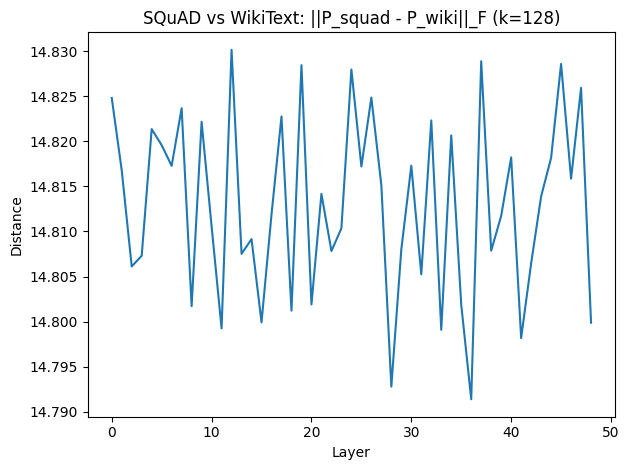

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def projector_from_evecs(Q, k=None):
    # Q: [d, d] or [d, r]
    if k is not None:
        Q = Q[:, :k]
    return Q @ Q.T

def layerwise_distance(pcas_a, pcas_b, k=128, mode="projector"):
    """
    pcas_a, pcas_b: lists/dicts indexed by layer, each entry has ["eigenvectors"]
    k: number of PCs to compare
    mode:
      - "basis": ||Qa - Qb||_F
      - "projector": ||QaQa^T - QbQb^T||_F  (recommended)
    """
    L = min(len(pcas_a), len(pcas_b))
    layers = []
    dists = []

    for l in range(L):
        if pcas_a[l] is None or pcas_b[l] is None:
            continue
        if "eigenvectors" not in pcas_a[l] or "eigenvectors" not in pcas_b[l]:
            continue

        Qa = pcas_a[l]["eigenvectors"].float().cpu()
        Qb = pcas_b[l]["eigenvectors"].float().cpu()

        if mode == "basis":
            Qa = Qa[:, :k]
            Qb = Qb[:, :k]
            dist = torch.linalg.norm(Qa - Qb, ord="fro").item()
        elif mode == "projector":
            Pa = projector_from_evecs(Qa, k=k)
            Pb = projector_from_evecs(Qb, k=k)
            dist = torch.linalg.norm(Pa - Pb, ord="fro").item()
        else:
            raise ValueError("mode must be 'basis' or 'projector'")

        layers.append(l)
        dists.append(dist)

    return np.array(layers), np.array(dists)



layers, d = layerwise_distance(pcas_squad_full, pcas_wikitext_full, k=128, mode="projector")

plt.figure()
plt.plot(layers, d)
plt.xlabel("Layer")
plt.ylabel("Distance")
plt.title("SQuAD vs WikiText: ||P_squad - P_wiki||_F (k=128)")
plt.tight_layout()
plt.show()
#plot with attn and mlp combined

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

def projector_from_evecs(Q, k=None):
    # Q: [d, d] (or [d, r])
    if k is not None:
        Q = Q[:, :k]
    return Q @ Q.T

def _as_list(obj):
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        try:
            keys = sorted(obj.keys())
            return [obj[k] for k in keys]
        except Exception:
            return list(obj.values())
    raise TypeError("pcas must be a list or dict of PCA entries")

def _filter_entries(pcas, which=None, require_enabled=None):
    entries = _as_list(pcas)
    out = {}
    for e in entries:
        if e is None or not isinstance(e, dict):
            continue
        if which is not None and e.get("type") != which:
            continue
        if require_enabled is not None and (e.get(require_enabled, True) is not True):
            continue
        layer = e.get("layer", None)
        if layer is None:
            continue
        if layer not in out:
            out[layer] = e
    return out

def get_evecs(pcas, layer_idx, which, require_enabled=None):
    """Return eigenvectors Q for a given layer after filtering."""
    d = _filter_entries(pcas, which=which, require_enabled=require_enabled)
    if layer_idx not in d:
        avail = sorted(d.keys())
        raise KeyError(f"Layer {layer_idx} not available for which='{which}'. Available layers: {avail[:10]} ...")
    return d[layer_idx]["eigenvectors"].float().cpu()

def layerwise_distance(
    pcas_a, pcas_b,
    k=128,
    mode="projector",
    which=None,
    require_enabled=None,
):
    """
    mode:
      - "basis":     ||Qa - Qb||_F
      - "projector": ||Pa - Pb||_F
      - "cosine":    1 - cosine(vec(Pa), vec(Pb))
    """
    Aa = _filter_entries(pcas_a, which=which, require_enabled=require_enabled)
    Bb = _filter_entries(pcas_b, which=which, require_enabled=require_enabled)

    common_layers = sorted(set(Aa.keys()) & set(Bb.keys()))
    layers, dists = [], []

    for l in common_layers:
        ea, eb = Aa[l], Bb[l]
        if "eigenvectors" not in ea or "eigenvectors" not in eb:
            continue

        Qa = ea["eigenvectors"].float().cpu()
        Qb = eb["eigenvectors"].float().cpu()

        if mode == "basis":
            Qa_k = Qa[:, :k]
            Qb_k = Qb[:, :k]
            dist = torch.linalg.norm(Qa_k - Qb_k, ord="fro").item()

        elif mode == "projector":
            Pa = projector_from_evecs(Qa, k=k)
            Pb = projector_from_evecs(Qb, k=k)
            dist = torch.linalg.norm(Pa - Pb, ord="fro").item()

        elif mode == "cosine":
            Pa = projector_from_evecs(Qa, k=k)
            Pb = projector_from_evecs(Qb, k=k)

            va = Pa.reshape(-1)
            vb = Pb.reshape(-1)

            # cosine similarity → distance
            cos_sim = F.cosine_similarity(va, vb, dim=0, eps=1e-12)
            dist = (1.0 - cos_sim).item()

        else:
            raise ValueError("mode must be 'basis', 'projector', or 'cosine'")

        layers.append(l)
        dists.append(dist)

    return np.array(layers), np.array(dists)

# ---- example usage ----
# layers, d = layerwise_distance(pcas_squad, pcas_wiki,
#                                which="attn_output", require_enabled="position_a_enabled",
#                                k=128, mode="projector")


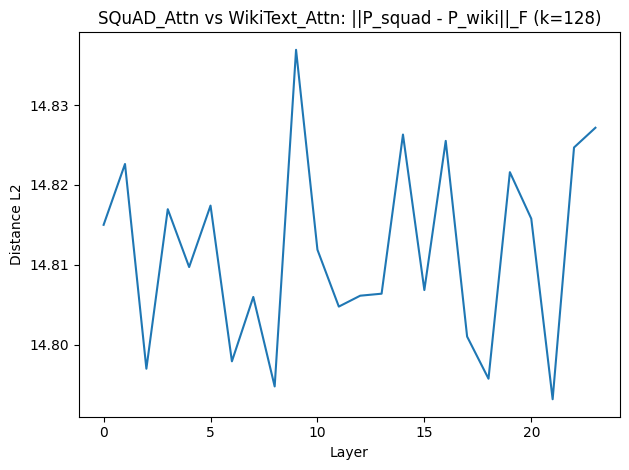

In [8]:
layers, d = layerwise_distance(pcas_squad_pos_a, pcas_wikitext_pos_a,
                                which="attn_output", require_enabled="position_a_enabled",
                                k=128, mode="projector")
plt.figure()
plt.plot(layers, d)
plt.xlabel("Layer")
plt.ylabel("Distance L2")
plt.title("SQuAD_Attn vs WikiText_Attn: ||P_squad - P_wiki||_F (k=128)")
plt.tight_layout()
plt.show()

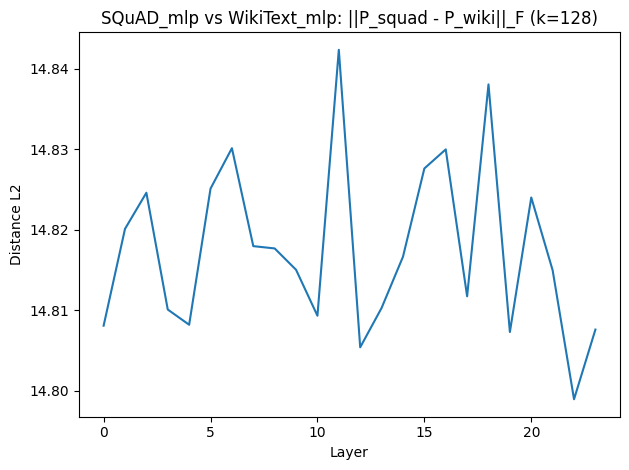

In [9]:
layers, d = layerwise_distance(pcas_squad_pos_b, pcas_wikitext_pos_b,
                                which="mlp_output", require_enabled="position_b_enabled",
                                k=128, mode="projector")
plt.figure()
plt.plot(layers, d)
plt.xlabel("Layer")
plt.ylabel("Distance L2")
plt.title("SQuAD_mlp vs WikiText_mlp: ||P_squad - P_wiki||_F (k=128)")
plt.tight_layout()
plt.show()

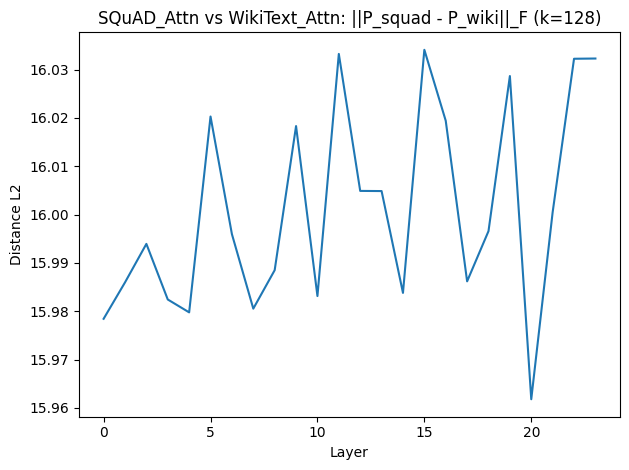

In [10]:
layers, d = layerwise_distance(pcas_squad_pos_a, pcas_wikitext_pos_a,
                                which="attn_output", require_enabled="position_a_enabled",
                                k=128, mode="basis")
plt.figure()
plt.plot(layers, d)
plt.xlabel("Layer")
plt.ylabel("Distance L2")
plt.title("SQuAD_Attn vs WikiText_Attn: ||P_squad - P_wiki||_F (k=128)")
plt.tight_layout()
plt.show()

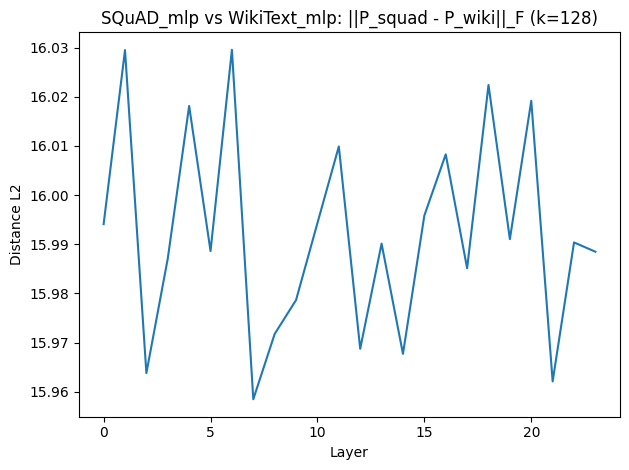

In [11]:
layers, d = layerwise_distance(pcas_squad_pos_b, pcas_wikitext_pos_b,
                                which="mlp_output", require_enabled="position_b_enabled",
                                k=128, mode="basis")
plt.figure()
plt.plot(layers, d)
plt.xlabel("Layer")
plt.ylabel("Distance L2")
plt.title("SQuAD_mlp vs WikiText_mlp: ||P_squad - P_wiki||_F (k=128)")
plt.tight_layout()
plt.show()

In [12]:
def grassman_distance(U, V, k, eps=1e-12):
    """
    Chordal Grassmann distance between k-dim subspaces spanned by columns of U, V.
    Returns sqrt( sum_i sin^2(theta_i) ) where theta_i are principal angles.
    """
    U = U[:, :k].float()
    V = V[:, :k].float()

    # Orthonormalize
    U, _ = torch.linalg.qr(U, mode="reduced")
    V, _ = torch.linalg.qr(V, mode="reduced")

    s = torch.linalg.svdvals(U.T @ V)
    s = torch.clamp(s, -1.0 + eps, 1.0 - eps)
    # sin^2(theta) = 1 - cos^2(theta) = 1 - s^2
    return torch.sqrt(torch.sum(1.0 - s**2)).item()


In [13]:
def plot_grassmann_vs_k(
    pcas_squad,
    pcas_wiki,
    layer_idx,
    which="attn_output",
    require_enabled=None,
    max_k=None,
    step=32,
    title=None,
):
    Qa = get_evecs(pcas_squad, layer_idx, which=which, require_enabled=require_enabled)
    Qb = get_evecs(pcas_wiki,  layer_idx, which=which, require_enabled=require_enabled)

    if max_k is None:
        max_k = min(Qa.shape[1], Qb.shape[1])

    k_values = list(range(1, max_k + 1, step))
    distances = [grassman_distance(Qa, Qb, k) for k in k_values]

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, distances, marker='o')
    plt.xlabel("k (Number of PCs)")
    plt.ylabel("Grassmann distance")
    if title is None:
        title = f"{which} | layer {layer_idx} | SQuAD vs WikiText"
        if require_enabled is not None:
            title += f" ({require_enabled}=True)"
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return np.array(k_values), np.array(distances)


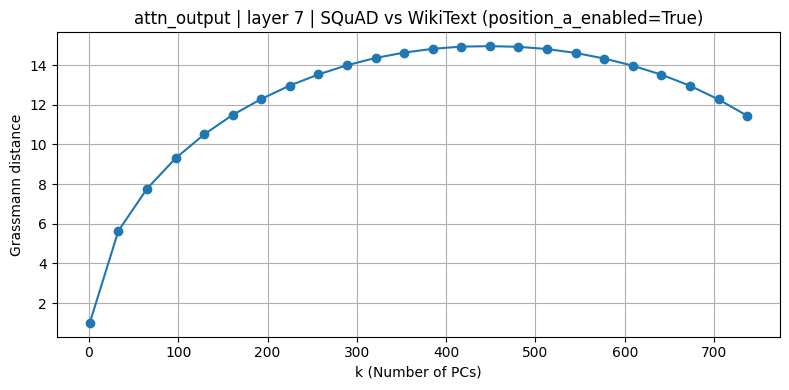

(array([  1,  33,  65,  97, 129, 161, 193, 225, 257, 289, 321, 353, 385,
        417, 449, 481, 513, 545, 577, 609, 641, 673, 705, 737]),
 array([ 0.99970466,  5.6360383 ,  7.7602706 ,  9.29796124, 10.50205326,
        11.48899841, 12.29029846, 12.96999931, 13.52762032, 13.99302483,
        14.35995293, 14.63108444, 14.82085323, 14.93195248, 14.95469952,
        14.92208767, 14.80984211, 14.61288357, 14.33238316, 13.96959496,
        13.51720333, 12.95990181, 12.2682972 , 11.44733238]))

In [14]:
plot_grassmann_vs_k(
    pcas_squad_pos_a, pcas_wikitext_pos_a,
    layer_idx=7,
    which="attn_output",
    require_enabled="position_a_enabled",
    max_k=768,
    step=32
)


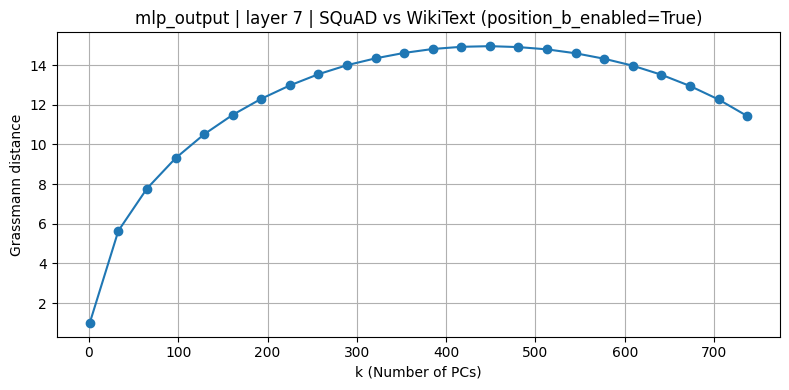

(array([  1,  33,  65,  97, 129, 161, 193, 225, 257, 289, 321, 353, 385,
        417, 449, 481, 513, 545, 577, 609, 641, 673, 705, 737]),
 array([ 0.99931622,  5.64309359,  7.77507401,  9.30593586, 10.51273251,
        11.49386692, 12.30509567, 12.97954464, 13.54494381, 14.00008488,
        14.34638309, 14.61970139, 14.81711769, 14.92742443, 14.95960617,
        14.91351128, 14.79812145, 14.60072708, 14.32461262, 13.97451782,
        13.51826286, 12.95172405, 12.27066803, 11.437006  ]))

In [15]:
plot_grassmann_vs_k(
    pcas_squad_pos_b, pcas_wikitext_pos_b,
    layer_idx=7,
    which="mlp_output",
    require_enabled="position_b_enabled",
    max_k=768,
    step=32
)

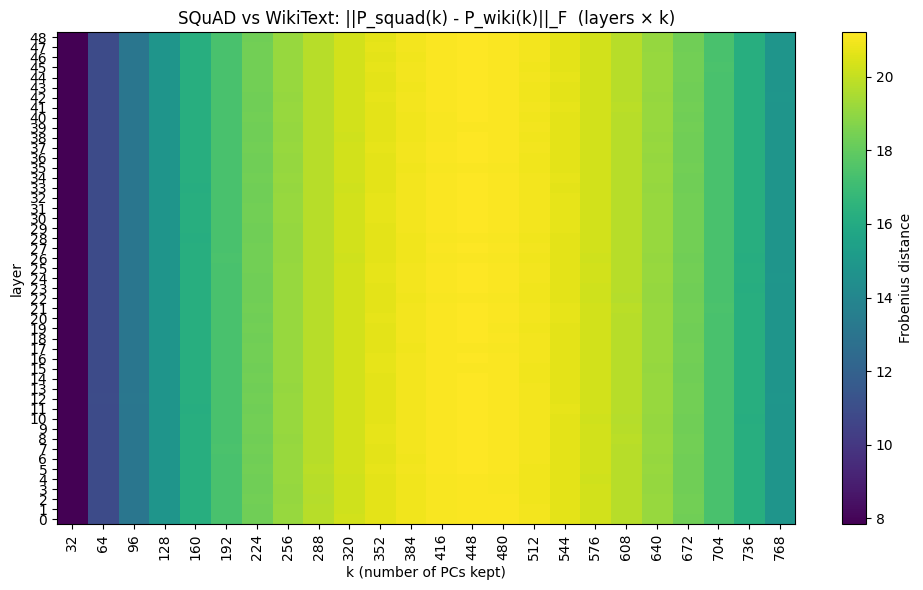

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def projector_from_evecs(Q, k):
    Qk = Q[:, :k]
    return Qk @ Qk.T

def layerwise_distance_for_k(pcas_a, pcas_b, k, mode="projector"):
    L = min(len(pcas_a), len(pcas_b))
    layers, dists = [], []

    for l in range(L):
        if pcas_a[l] is None or pcas_b[l] is None:
            continue
        if "eigenvectors" not in pcas_a[l] or "eigenvectors" not in pcas_b[l]:
            continue

        Qa = pcas_a[l]["eigenvectors"].float().cpu()
        Qb = pcas_b[l]["eigenvectors"].float().cpu()

        if mode == "basis":
            A = Qa[:, :k]
            B = Qb[:, :k]
            dist = torch.linalg.norm(A - B, ord="fro").item()
        elif mode == "projector":
            Pa = projector_from_evecs(Qa, k=k)
            Pb = projector_from_evecs(Qb, k=k)
            dist = torch.linalg.norm(Pa - Pb, ord="fro").item()
        else:
            raise ValueError("mode must be 'basis' or 'projector'")

        layers.append(l)
        dists.append(dist)

    return np.array(layers), np.array(dists)

def distance_matrix_layers_vs_k(pcas_a, pcas_b, max_k=768, step=32, mode="projector"):
    ks = np.arange(step, max_k + 1, step)
    # get layer list from one run (k=step) to define consistent indexing
    layers, _ = layerwise_distance_for_k(pcas_a, pcas_b, k=step, mode=mode)
    nL = len(layers)
    nK = len(ks)

    D = np.full((nL, nK), np.nan, dtype=np.float32)

    for j, k in enumerate(ks):
        layers_k, d_k = layerwise_distance_for_k(pcas_a, pcas_b, k=k, mode=mode)

        # map distances to the same layer ordering
        idx = {layer: i for i, layer in enumerate(layers)}
        for layer, dist in zip(layers_k, d_k):
            if layer in idx:
                D[idx[layer], j] = dist

    return layers, ks, D

# ---- run ----
layers, ks, D = distance_matrix_layers_vs_k(
    pcas_squad_full, pcas_wikitext_full, max_k=768, step=32, mode="projector"
)

# heatmap
plt.figure(figsize=(10, 6))
plt.imshow(D, aspect="auto", origin="lower")
plt.colorbar(label="Frobenius distance")
plt.xticks(range(len(ks)), ks, rotation=90)
plt.yticks(range(len(layers)), layers)
plt.xlabel("k (number of PCs kept)")
plt.ylabel("layer")
plt.title("SQuAD vs WikiText: ||P_squad(k) - P_wiki(k)||_F  (layers × k)")
plt.tight_layout()
plt.show()

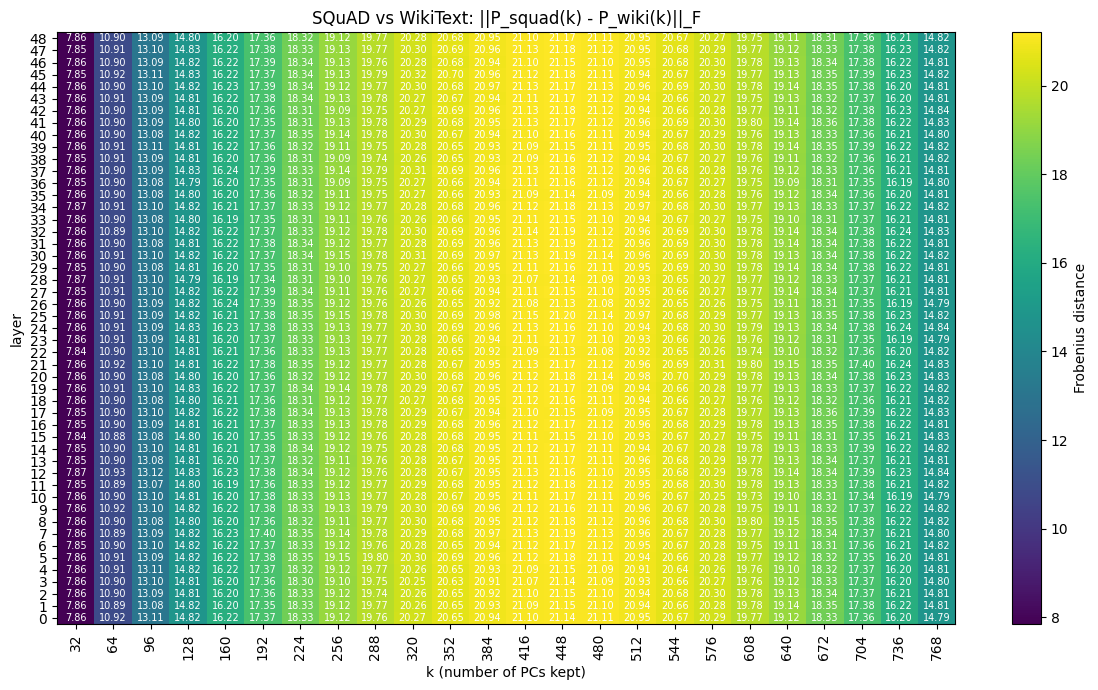

In [32]:
plt.figure(figsize=(12, 7))
im = plt.imshow(D, aspect="auto", origin="lower")
plt.colorbar(im, label="Frobenius distance")

plt.xticks(range(len(ks)), ks, rotation=90)
plt.yticks(range(len(layers)), layers)
plt.xlabel("k (number of PCs kept)")
plt.ylabel("layer")
plt.title("SQuAD vs WikiText: ||P_squad(k) - P_wiki(k)||_F")

# annotate values
for i in range(D.shape[0]):      # layers
    for j in range(D.shape[1]):  # ks
        if not np.isnan(D[i, j]):
            plt.text(
                j, i,
                f"{D[i, j]:.2f}",
                ha="center", va="center",
                fontsize=7, color="white"
            )

plt.tight_layout()
plt.show()


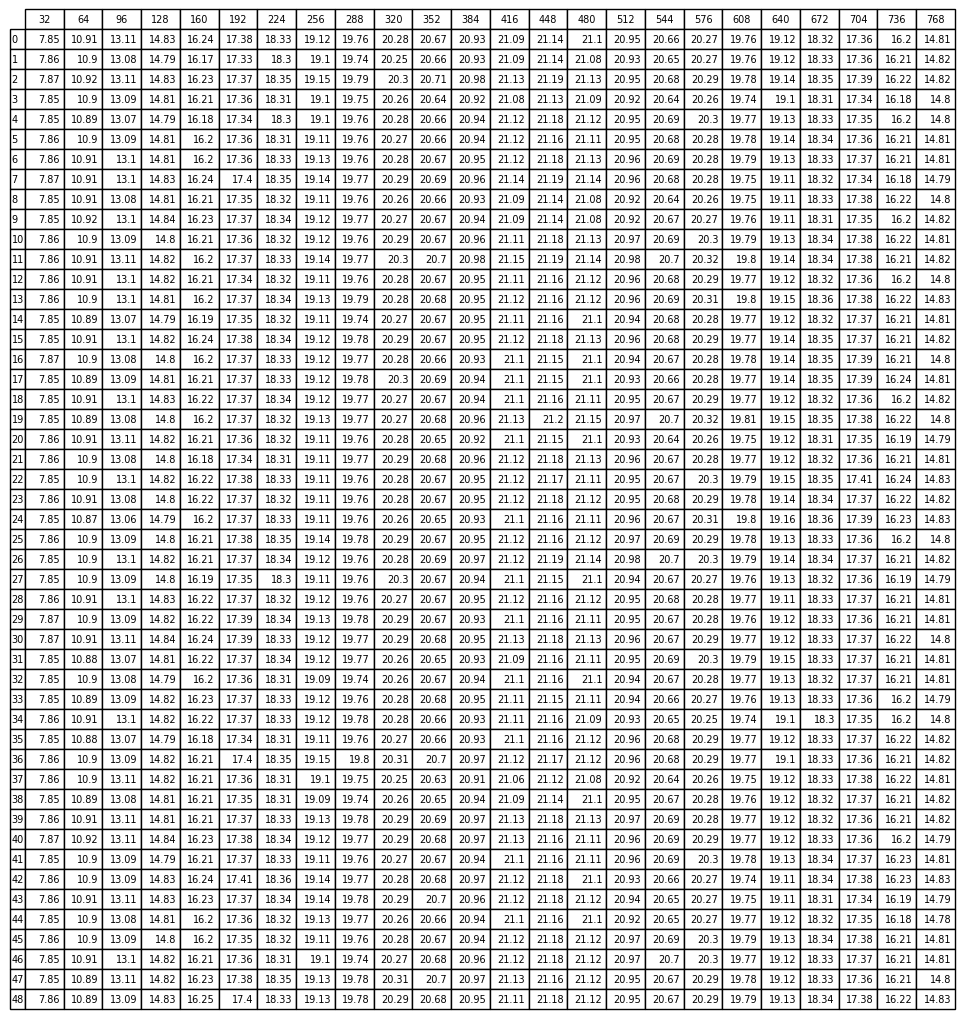

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

table = ax.table(
    cellText=np.round(D, 2),
    rowLabels=layers,
    colLabels=ks,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.0, 1.2)

plt.title("", pad=20)
plt.show()


In [ ]:
import subprocess
import os
from datetime import datetime
from itertools import product

# Ablation configurations to test
ABLATION_CONFIGS = ["full", "position_a_only", "position_b_only"]

# Calibration datasets to compare
CAL_DATASETS = ["wikitext2", "squad2"]

def run_slicegpt_ablation(dataset, sparsity, ablation_config):
    """Run SliceGPT with specific ablation configuration."""

    # Include ablation in log/dir names
    log_name = f"{dataset}_s{sparsity:.2f}_{ablation_config}".replace(".", "p") + ".txt"
    log_path = os.path.join(LOG_DIR, log_name)

    save_dir = os.path.join(MODEL_DIR, f"{dataset}_s{sparsity:.2f}_{ablation_config}".replace(".", "p"))
    os.makedirs(save_dir, exist_ok=True)

    cmd = [
        "python", "-B",  # <-- Add this flag to disable bytecode caching
        "/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications/experiments/run_slicegpt.py",
        "--model", "Qwen/Qwen2-0.5B",
        "--cal-dataset", dataset,
        "--save-dir", save_dir,
        "--sparsity", str(sparsity),
        "--device", "cuda:0",
        "--no-wandb",
        "--cal-batch-size", "8",
        "--ablation-config", ablation_config,  # <-- NEW: ablation flag
        "--save-rotation-matrices" # flag to save the rotation matrices
    ]

    print("\n=====================================================")
    print(f"Running: dataset={dataset}, sparsity={sparsity}, ablation={ablation_config}")
    print("Command:", " ".join(cmd))
    print("Log file:", log_path)
    print("Start:", datetime.now())
    print("=====================================================\n")

    with open(log_path, "w") as f:
        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            print(line, end="")
            f.write(line)

    ret = process.wait()
    print("\nFinished with return code:", ret)
    print("End:", datetime.now())





In [ ]:
#we do the first run just getting the rotation matrices with sparsity = 0.0
datasets = ["wikitext2", "squad"]
sparsities = [0.0]

# CORRECT - iterate over each config
for dataset in datasets:
    for s in sparsities:
        for ablation_config in ABLATION_CONFIGS:
            run_slicegpt_ablation(dataset, s, ablation_config)  # ✅ string
